# IndoBERT Clickbait Detection Experiments

This notebook reproduces the original IndoBERT experiment pipeline using the CLICK-ID `all_agree.csv` dataset.

Experiments:
1. Imbalance
2. Balance
3. Imbalance + Augmentation
4. Balance + Augmentation

The original settings are retained:
- fixed padding to 96 tokens
- weighted F1 for checkpoint selection
- bootstrap oversampling
- random word swap and deletion
- the same split, seed, and training hyperparameters


## 1. Install Dependencies

In [1]:
# Run once in a fresh Colab runtime, then restart the runtime.
!pip uninstall -y peft transformers accelerate tokenizers
!pip install -q transformers==4.48.3 accelerate==1.3.0 tokenizers==0.21.0 datasets evaluate nlpaug scikit-learn

print("Installation completed. Restart the runtime before continuing.")


Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
Found existing installation: transformers 5.10.2
Uninstalling transformers-5.10.2:
  Successfully uninstalled transformers-5.10.2
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.6/336.6 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Google Drive and Project Paths

In [3]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/NLPAOL_V3")

DATA_DIR = PROJECT_DIR / "data_1" / "annotated" / "combined" / "csv"
CSV_PATH = DATA_DIR / "all_agree.csv"

if not CSV_PATH.exists():
    matches = list(PROJECT_DIR.rglob("all_agree.csv"))

    if not matches:
        raise FileNotFoundError(
            f"all_agree.csv was not found under {PROJECT_DIR}"
        )

    CSV_PATH = matches[0]
    DATA_DIR = CSV_PATH.parent

OUTPUT_ROOT = PROJECT_DIR / "output_indobert_final"
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
RESULTS_DIR = OUTPUT_ROOT / "results"
DEPLOY_ROOT = OUTPUT_ROOT / "final_deploy"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DEPLOY_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR :", PROJECT_DIR)
print("DATA_DIR    :", DATA_DIR)
print("CSV_PATH    :", CSV_PATH)
print("OUTPUT_ROOT :", OUTPUT_ROOT)
print("CSV_EXISTS  :", CSV_PATH.exists())


Mounted at /content/drive
PROJECT_DIR : /content/drive/MyDrive/NLPAOL_V3
DATA_DIR    : /content/drive/MyDrive/NLPAOL_V3/data_1/annotated/combined/csv
CSV_PATH    : /content/drive/MyDrive/NLPAOL_V3/data_1/annotated/combined/csv/all_agree.csv
OUTPUT_ROOT : /content/drive/MyDrive/NLPAOL_V3/output_indobert_final
CSV_EXISTS  : True


## 3. Imports

In [4]:
import gc
import json
import random
import re
import shutil
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
import datasets.config as datasets_config
import nlpaug.augmenter.word as naw

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

import transformers
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()

# Prevent an optional torchvision import from interrupting Colab execution.
datasets_config.TORCHVISION_AVAILABLE = False

print("Transformers version:", transformers.__version__)
print("Torch version       :", torch.__version__)
print("CUDA available      :", torch.cuda.is_available())


Transformers version: 4.48.3
Torch version       : 2.11.0+cu128
CUDA available      : True


## 4. Experiment Configuration

In [5]:
MODEL_NAME = "indobenchmark/indobert-base-p1"

MAX_LENGTH = 96
BATCH_SIZE = 8
EPOCHS = 10
LR = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
PATIENCE = 3
SEED = 42

TEXT_COL = "title"
LABEL_COL = "label"

LABEL2ID = {
    "non-clickbait": 0,
    "clickbait": 1,
}

ID2LABEL = {
    0: "non-clickbait",
    1: "clickbait",
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

set_seed(SEED)

print("Model       :", MODEL_NAME)
print("Device      :", DEVICE)
print("Max length  :", MAX_LENGTH)
print("Batch size  :", BATCH_SIZE)
print("Epochs      :", EPOCHS)
print("Learning rate:", LR)


Model       : indobenchmark/indobert-base-p1
Device      : cuda
Max length  : 96
Batch size  : 8
Epochs      : 10
Learning rate: 2e-05


## 5. Load Dataset

In [6]:
df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())

if TEXT_COL not in df.columns:
    raise ValueError(
        f"Text column '{TEXT_COL}' was not found. "
        f"Available columns: {df.columns.tolist()}"
    )

if LABEL_COL not in df.columns:
    raise ValueError(
        f"Label column '{LABEL_COL}' was not found. "
        f"Available columns: {df.columns.tolist()}"
    )

print("\nMissing values:")
print(df[[TEXT_COL, LABEL_COL]].isnull().sum())

print("\nOriginal label distribution:")
print(df[LABEL_COL].value_counts(dropna=False))


Dataset shape: (8613, 3)
Columns: ['title', 'label', 'label_score']


,title,label,label_score
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",non-clickbait,0
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,non-clickbait,0
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,clickbait,1
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",non-clickbait,0
4,MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...,non-clickbait,0



Missing values:
title    0
label    0
dtype: int64

Original label distribution:
label
non-clickbait    5297
clickbait        3316
Name: count, dtype: int64


## 6. Text Cleaning and Label Normalization

In [7]:
def clean_text(text: str) -> str:
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^\w\s.,!?-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_label(label: str) -> str:
    label = str(label).strip().lower()
    label = label.replace("_", "-")
    label = re.sub(r"\s+", "-", label)

    if label in ["clickbait", "cb", "1"]:
        return "clickbait"

    if label in [
        "non-clickbait",
        "nonclickbait",
        "non-click-bait",
        "noncb",
        "not-clickbait",
        "0",
    ]:
        return "non-clickbait"

    return label


df_raw = df.copy()
df_raw = df_raw[[TEXT_COL, LABEL_COL]].dropna().copy()

df_raw[TEXT_COL] = df_raw[TEXT_COL].astype(str)
df_raw[LABEL_COL] = df_raw[LABEL_COL].apply(normalize_label)

df_raw["title_clean"] = df_raw[TEXT_COL].apply(clean_text)
df_raw["label_id"] = df_raw[LABEL_COL].map(LABEL2ID)

invalid_labels = (
    df_raw[df_raw["label_id"].isna()][LABEL_COL]
    .unique()
)

if len(invalid_labels) > 0:
    raise ValueError(
        f"Invalid labels were found: {invalid_labels}"
    )

df_raw["label_id"] = df_raw["label_id"].astype(int)
df_raw = (
    df_raw[df_raw["title_clean"].str.len() > 0]
    .reset_index(drop=True)
)

print("Cleaned dataset shape:", df_raw.shape)
display(
    df_raw[
        ["title_clean", LABEL_COL, "label_id"]
    ].head()
)

print("\nCleaned label distribution:")
print(df_raw[LABEL_COL].value_counts())


Cleaned dataset shape: (8613, 4)


,title_clean,label,label_id
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",non-clickbait,0
1,Malaysia Sudutkan RI Isu Kabut Asap hingga Inv...,non-clickbait,0
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,clickbait,1
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",non-clickbait,0
4,MPR Amandemen UUD 1945 Tak Akan Melebar ke Man...,non-clickbait,0



Cleaned label distribution:
label
non-clickbait    5297
clickbait        3316
Name: count, dtype: int64


## 7. Headline Length Check

In [8]:
word_lengths = df_raw["title_clean"].apply(
    lambda text: len(text.split())
)

print("Word-count distribution:")
print(word_lengths.describe().round(1))
print(f"Maximum words        : {word_lengths.max()}")
print(
    f"99th percentile      : "
    f"{word_lengths.quantile(0.99):.0f} words"
)
print(f"MAX_LENGTH configured: {MAX_LENGTH} tokens")

estimated_truncation = (
    word_lengths > MAX_LENGTH
).mean() * 100

print(
    f"Estimated rows above MAX_LENGTH: "
    f"{estimated_truncation:.1f}%"
)


Word-count distribution:
count    8613.0
mean        9.7
std         2.3
min         2.0
25%         8.0
50%         9.0
75%        11.0
max        19.0
Name: title_clean, dtype: float64
Maximum words        : 19
99th percentile      : 15 words
MAX_LENGTH configured: 96 tokens
Estimated rows above MAX_LENGTH: 0.0%


## 8. Train, Validation, and Test Split

In [9]:
def make_splits(
    df_input: pd.DataFrame,
    seed: int = SEED,
):
    train_val, test = train_test_split(
        df_input,
        test_size=0.10,
        stratify=df_input["label_id"],
        random_state=seed,
    )

    train, val = train_test_split(
        train_val,
        test_size=0.1111,
        stratify=train_val["label_id"],
        random_state=seed,
    )

    return (
        train.reset_index(drop=True),
        val.reset_index(drop=True),
        test.reset_index(drop=True),
    )


df_raw["_row_id"] = range(len(df_raw))

train_raw, val_raw, test_raw = make_splits(
    df_raw
)

print(f"Train: {len(train_raw):,}")
print(f"Val  : {len(val_raw):,}")
print(f"Test : {len(test_raw):,}")

print("\nTrain distribution:")
print(train_raw[LABEL_COL].value_counts())

print("\nValidation distribution:")
print(val_raw[LABEL_COL].value_counts())

print("\nTest distribution:")
print(test_raw[LABEL_COL].value_counts())

train_ids = set(train_raw["_row_id"])
val_ids = set(val_raw["_row_id"])
test_ids = set(test_raw["_row_id"])

assert not train_ids & val_ids
assert not train_ids & test_ids
assert not val_ids & test_ids

print("\nSplit leakage check passed.")


Train: 6,889
Val  : 862
Test : 862

Train distribution:
label
non-clickbait    4237
clickbait        2652
Name: count, dtype: int64

Validation distribution:
label
non-clickbait    530
clickbait        332
Name: count, dtype: int64

Test distribution:
label
non-clickbait    530
clickbait        332
Name: count, dtype: int64

Split leakage check passed.


## 9. Training Set Variants

In [10]:
train_imbalance = train_raw.copy()

print("[Imbalance]")
print(train_imbalance[LABEL_COL].value_counts())


def balance_by_bootstrap(
    df_input: pd.DataFrame,
    seed: int = SEED,
) -> pd.DataFrame:
    majority_label = (
        df_input[LABEL_COL]
        .value_counts()
        .idxmax()
    )
    minority_label = (
        df_input[LABEL_COL]
        .value_counts()
        .idxmin()
    )

    majority_count = (
        df_input[LABEL_COL] == majority_label
    ).sum()

    df_majority = df_input[
        df_input[LABEL_COL] == majority_label
    ]
    df_minority = df_input[
        df_input[LABEL_COL] == minority_label
    ]

    df_minority_up = resample(
        df_minority,
        replace=True,
        n_samples=majority_count,
        random_state=seed,
    )

    return (
        pd.concat(
            [df_majority, df_minority_up]
        )
        .sample(
            frac=1,
            random_state=seed,
        )
        .reset_index(drop=True)
    )


train_balance = balance_by_bootstrap(
    train_raw
)

print("\n[Balance]")
print(train_balance[LABEL_COL].value_counts())


def eda_augment(
    texts,
    seed: int = SEED,
):
    random.seed(seed)
    np.random.seed(seed)

    aug_swap = naw.RandomWordAug(
        action="swap",
        aug_p=0.1,
    )
    aug_delete = naw.RandomWordAug(
        action="delete",
        aug_p=0.1,
    )

    operations = [
        aug_swap,
        aug_delete,
    ]

    augmented_texts = []

    for text in texts:
        operation = random.choice(
            operations
        )

        try:
            result = operation.augment(
                str(text),
                n=1,
            )

            if (
                isinstance(result, list)
                and len(result) > 0
            ):
                augmented_texts.append(
                    result[0]
                )
            else:
                augmented_texts.append(
                    text
                )

        except Exception:
            augmented_texts.append(text)

    return augmented_texts


print("\nCreating Balance + Augment data...")

balance_aug_texts = eda_augment(
    train_balance["title_clean"].tolist()
)

df_balance_aug = train_balance.copy()
df_balance_aug["title_clean"] = (
    balance_aug_texts
)

train_balance_clean = train_balance.drop(
    columns=["_row_id"],
    errors="ignore",
)
df_balance_aug_clean = df_balance_aug.drop(
    columns=["_row_id"],
    errors="ignore",
)

train_balance_augment = (
    pd.concat(
        [
            train_balance_clean,
            df_balance_aug_clean,
        ]
    )
    .sample(
        frac=1,
        random_state=SEED,
    )
    .reset_index(drop=True)
)

print("[Balance + Augment]")
print(
    train_balance_augment[
        LABEL_COL
    ].value_counts()
)
print(
    "Total:",
    f"{len(train_balance_augment):,}",
)


[Imbalance]
label
non-clickbait    4237
clickbait        2652
Name: count, dtype: int64

[Balance]
label
clickbait        4237
non-clickbait    4237
Name: count, dtype: int64

Creating Balance + Augment data...
[Balance + Augment]
label
clickbait        8474
non-clickbait    8474
Name: count, dtype: int64
Total: 16,948


## 10. Tokenizer and Dataset Conversion

In [11]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


def df_to_hf_dataset(
    df_input: pd.DataFrame,
) -> Dataset:
    temp_df = df_input[
        ["title_clean", "label_id"]
    ].copy()

    temp_df = temp_df.rename(
        columns={"label_id": "labels"}
    )

    dataset = Dataset.from_pandas(
        temp_df,
        preserve_index=False,
    )

    dataset = dataset.map(
        lambda batch: tokenizer(
            batch["title_clean"],
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
        ),
        batched=True,
        batch_size=512,
    )

    dataset = dataset.remove_columns(
        ["title_clean"]
    )
    dataset.set_format("torch")

    return dataset


val_ds = df_to_hf_dataset(val_raw)
test_ds = df_to_hf_dataset(test_raw)

print("Validation dataset:", val_ds)
print("Test dataset      :", test_ds)


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/862 [00:00<?, ? examples/s]

Map:   0%|          | 0/862 [00:00<?, ? examples/s]

Validation dataset: Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 862
})
Test dataset      : Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 862
})


## 11. Evaluation Metrics

In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    if isinstance(logits, tuple):
        logits = logits[0]

    preds = np.argmax(
        logits,
        axis=-1,
    )

    return {
        "f1": f1_score(
            labels,
            preds,
            average="weighted",
            zero_division=0,
        ),
        "f1_macro": f1_score(
            labels,
            preds,
            average="macro",
            zero_division=0,
        ),
        "precision": precision_score(
            labels,
            preds,
            average="weighted",
            zero_division=0,
        ),
        "recall": recall_score(
            labels,
            preds,
            average="weighted",
            zero_division=0,
        ),
        "accuracy": float(
            (preds == labels).mean()
        ),
    }


## 12. Training and Evaluation

In [13]:
def save_binary_config(
    model_dir: Path,
):
    config_path = model_dir / "config.json"

    with open(
        config_path,
        "r",
        encoding="utf-8",
    ) as file:
        config = json.load(file)

    config["num_labels"] = 2
    config["_num_labels"] = 2
    config["id2label"] = {
        "0": "non-clickbait",
        "1": "clickbait",
    }
    config["label2id"] = {
        "non-clickbait": 0,
        "clickbait": 1,
    }
    config["problem_type"] = (
        "single_label_classification"
    )

    with open(
        config_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            config,
            file,
            indent=2,
            ensure_ascii=False,
        )


def train_and_evaluate(
    train_df,
    val_ds,
    test_ds,
    experiment_name,
    model_name=MODEL_NAME,
):
    print(f"\n{'=' * 70}")
    print("Experiment :", experiment_name)
    print("Train rows :", f"{len(train_df):,}")
    print(
        train_df[
            LABEL_COL
        ].value_counts().to_string()
    )
    print("=" * 70)

    set_seed(SEED)

    train_ds = df_to_hf_dataset(
        train_df
    )

    model = (
        AutoModelForSequenceClassification
        .from_pretrained(
            model_name,
            num_labels=2,
            id2label=ID2LABEL,
            label2id=LABEL2ID,
            ignore_mismatched_sizes=True,
        )
    )

    run_dir = (
        CHECKPOINT_DIR
        / experiment_name
    )

    if run_dir.exists():
        shutil.rmtree(run_dir)

    run_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    training_args = TrainingArguments(
        output_dir=str(run_dir),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=(
            BATCH_SIZE * 2
        ),
        gradient_accumulation_steps=2,
        learning_rate=LR,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        logging_steps=50,
        seed=SEED,
        fp16=torch.cuda.is_available(),
        report_to="none",
        save_total_limit=1,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=PATIENCE
            )
        ],
    )

    trainer.train()

    val_metrics = trainer.evaluate(
        val_ds
    )
    test_output = trainer.predict(
        test_ds
    )

    test_labels = (
        test_output.label_ids
    )
    test_logits = (
        test_output.predictions
    )

    if isinstance(
        test_logits,
        tuple,
    ):
        test_logits = test_logits[0]

    test_preds = np.argmax(
        test_logits,
        axis=-1,
    )

    report = classification_report(
        test_labels,
        test_preds,
        target_names=[
            "non-clickbait",
            "clickbait",
        ],
        digits=4,
        zero_division=0,
    )

    cm = confusion_matrix(
        test_labels,
        test_preds,
        labels=[0, 1],
    )

    print("\nTest classification report")
    print(report)

    report_path = (
        RESULTS_DIR
        / f"{experiment_name}_report.txt"
    )
    report_path.write_text(
        (
            f"Experiment: {experiment_name}\n"
            f"Model: {model_name}\n\n"
            f"{report}\n"
        ),
        encoding="utf-8",
    )

    cm_path = (
        RESULTS_DIR
        / f"{experiment_name}_confusion_matrix.csv"
    )
    pd.DataFrame(
        cm,
        index=[
            "true_non_clickbait",
            "true_clickbait",
        ],
        columns=[
            "pred_non_clickbait",
            "pred_clickbait",
        ],
    ).to_csv(cm_path)

    fig, axis = plt.subplots(
        figsize=(4.5, 4.0)
    )

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Non-Clickbait",
            "Clickbait",
        ],
    ).plot(
        ax=axis,
        colorbar=False,
    )

    axis.set_title(
        experiment_name
    )
    plt.tight_layout()

    cm_figure_path = (
        RESULTS_DIR
        / f"{experiment_name}_confusion_matrix.png"
    )
    plt.savefig(
        cm_figure_path,
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

    best_model_dir = (
        run_dir
        / "best_model"
    )
    trainer.save_model(
        str(best_model_dir)
    )
    tokenizer.save_pretrained(
        str(best_model_dir)
    )
    save_binary_config(
        best_model_dir
    )

    result = {
        "experiment": experiment_name,
        "model": model_name,
        "train_rows": len(train_df),
        "val_f1": round(
            val_metrics.get(
                "eval_f1_macro",
                0,
            ),
            4,
        ),
        "val_f1_macro": round(
            val_metrics.get(
                "eval_f1_macro",
                0,
            ),
            4,
        ),
        "test_accuracy": round(
            float(
                (
                    test_preds
                    == test_labels
                ).mean()
            ),
            4,
        ),
        "test_precision": round(
            precision_score(
                test_labels,
                test_preds,
                average="macro",
                zero_division=0,
            ),
            4,
        ),
        "test_recall": round(
            recall_score(
                test_labels,
                test_preds,
                average="macro",
                zero_division=0,
            ),
            4,
        ),
        "test_f1": round(
            f1_score(
                test_labels,
                test_preds,
                average="weighted",
                zero_division=0,
            ),
            4,
        ),
        "test_f1_weighted": round(
            f1_score(
                test_labels,
                test_preds,
                average="weighted",
                zero_division=0,
            ),
            4,
        ),
        "test_f1_macro": round(
            f1_score(
                test_labels,
                test_preds,
                average="macro",
                zero_division=0,
            ),
            4,
        ),
        "best_checkpoint": (
            trainer.state
            .best_model_checkpoint
        ),
        "best_model_dir": str(
            best_model_dir
        ),
    }

    del model
    del trainer
    del train_ds

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


## 13. Experiment 1: Imbalance


Experiment : indobert_imbalance
Train rows : 6,889
label
non-clickbait    4237
clickbait        2652


Map:   0%|          | 0/6889 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

{'loss': 0.7385, 'grad_norm': 6.377810001373291, 'learning_rate': 2.320185614849188e-06, 'epoch': 0.11600928074245939}
{'loss': 0.4223, 'grad_norm': 3.8474576473236084, 'learning_rate': 4.640371229698376e-06, 'epoch': 0.23201856148491878}
{'loss': 0.2497, 'grad_norm': 13.316307067871094, 'learning_rate': 6.960556844547565e-06, 'epoch': 0.3480278422273782}
{'loss': 0.2168, 'grad_norm': 21.129257202148438, 'learning_rate': 9.280742459396753e-06, 'epoch': 0.46403712296983757}
{'loss': 0.1956, 'grad_norm': 1.918036937713623, 'learning_rate': 1.160092807424594e-05, 'epoch': 0.580046403712297}
{'loss': 0.2161, 'grad_norm': 9.765225410461426, 'learning_rate': 1.392111368909513e-05, 'epoch': 0.6960556844547564}
{'loss': 0.1904, 'grad_norm': 0.5957614183425903, 'learning_rate': 1.624129930394432e-05, 'epoch': 0.8120649651972158}
{'loss': 0.2142, 'grad_norm': 9.398798942565918, 'learning_rate': 1.8561484918793505e-05, 'epoch': 0.9280742459396751}
{'eval_loss': 0.15848246216773987, 'eval_f1': 0.9

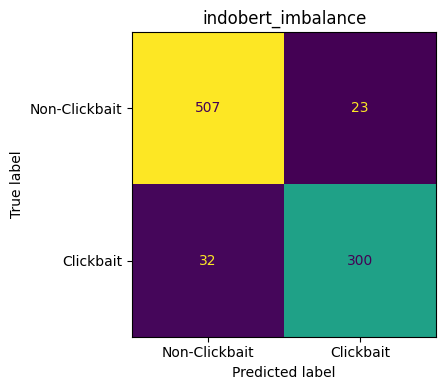

,experiment,model,train_rows,val_f1,val_f1_macro,test_accuracy,test_precision,test_recall,test_f1,test_f1_weighted,test_f1_macro,best_checkpoint,best_model_dir
0,indobert_imbalance,indobenchmark/indobert-base-p1,6889,0.9495,0.9495,0.9362,0.9347,0.9301,0.936,0.936,0.9323,/content/drive/MyDrive/NLPAOL_V3/output_indobe...,/content/drive/MyDrive/NLPAOL_V3/output_indobe...


In [14]:
all_results = []

result = train_and_evaluate(
    train_imbalance,
    val_ds,
    test_ds,
    "indobert_imbalance",
)

all_results.append(result)
display(pd.DataFrame(all_results))


## 14. Experiment 2: Balance


Experiment : indobert_balance
Train rows : 8,474
label
clickbait        4237
non-clickbait    4237


Map:   0%|          | 0/8474 [00:00<?, ? examples/s]

{'loss': 0.7077, 'grad_norm': 4.789144515991211, 'learning_rate': 1.8867924528301889e-06, 'epoch': 0.09433962264150944}
{'loss': 0.4554, 'grad_norm': 5.081615447998047, 'learning_rate': 3.7735849056603777e-06, 'epoch': 0.18867924528301888}
{'loss': 0.2856, 'grad_norm': 10.112757682800293, 'learning_rate': 5.660377358490566e-06, 'epoch': 0.2830188679245283}
{'loss': 0.2495, 'grad_norm': 6.473211765289307, 'learning_rate': 7.5471698113207555e-06, 'epoch': 0.37735849056603776}
{'loss': 0.1854, 'grad_norm': 10.530723571777344, 'learning_rate': 9.433962264150944e-06, 'epoch': 0.4716981132075472}
{'loss': 0.2198, 'grad_norm': 14.045442581176758, 'learning_rate': 1.1320754716981132e-05, 'epoch': 0.5660377358490566}
{'loss': 0.2078, 'grad_norm': 8.489840507507324, 'learning_rate': 1.320754716981132e-05, 'epoch': 0.660377358490566}
{'loss': 0.1885, 'grad_norm': 3.3564436435699463, 'learning_rate': 1.5094339622641511e-05, 'epoch': 0.7547169811320755}
{'loss': 0.1743, 'grad_norm': 25.929620742797

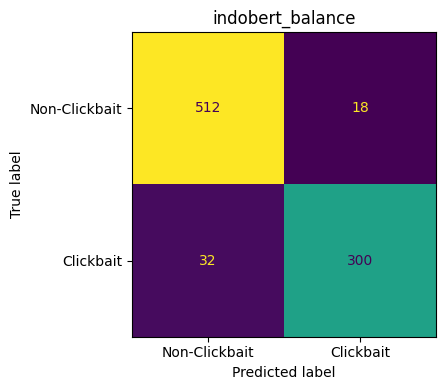

,experiment,model,train_rows,val_f1,val_f1_macro,test_accuracy,test_precision,test_recall,test_f1,test_f1_weighted,test_f1_macro,best_checkpoint,best_model_dir
0,indobert_imbalance,indobenchmark/indobert-base-p1,6889,0.9495,0.9495,0.9362,0.9347,0.9301,0.9360,0.9360,0.9323,/content/drive/MyDrive/NLPAOL_V3/output_indobe...,/content/drive/MyDrive/NLPAOL_V3/output_indobe...
1,indobert_balance,indobenchmark/indobert-base-p1,8474,0.9570,0.9570,0.9420,0.9423,0.9348,0.9417,0.9417,0.9383,/content/drive/MyDrive/NLPAOL_V3/output_indobe...,/content/drive/MyDrive/NLPAOL_V3/output_indobe...


In [15]:
result = train_and_evaluate(
    train_balance,
    val_ds,
    test_ds,
    "indobert_balance",
)

all_results.append(result)
display(pd.DataFrame(all_results))


## 15. Experiment 3: Imbalance + Augmentation

Creating Imbalance + Augment data...
[Imbalance + Augment]
label
non-clickbait    8474
clickbait        5304
Name: count, dtype: int64

Experiment : indobert_imbalance_augment
Train rows : 13,778
label
non-clickbait    8474
clickbait        5304


Map:   0%|          | 0/13778 [00:00<?, ? examples/s]

{'loss': 0.7792, 'grad_norm': 3.97767972946167, 'learning_rate': 1.1614401858304298e-06, 'epoch': 0.05803830528148578}
{'loss': 0.5242, 'grad_norm': 4.558851718902588, 'learning_rate': 2.3228803716608596e-06, 'epoch': 0.11607661056297155}
{'loss': 0.3503, 'grad_norm': 6.0098981857299805, 'learning_rate': 3.48432055749129e-06, 'epoch': 0.17411491584445735}
{'loss': 0.2475, 'grad_norm': 10.067021369934082, 'learning_rate': 4.645760743321719e-06, 'epoch': 0.2321532211259431}
{'loss': 0.2395, 'grad_norm': 2.0829427242279053, 'learning_rate': 5.8072009291521495e-06, 'epoch': 0.2901915264074289}
{'loss': 0.2283, 'grad_norm': 8.379976272583008, 'learning_rate': 6.96864111498258e-06, 'epoch': 0.3482298316889147}
{'loss': 0.2324, 'grad_norm': 16.9683837890625, 'learning_rate': 8.130081300813009e-06, 'epoch': 0.4062681369704005}
{'loss': 0.2039, 'grad_norm': 7.320624828338623, 'learning_rate': 9.291521486643439e-06, 'epoch': 0.4643064422518862}
{'loss': 0.2387, 'grad_norm': 4.285495758056641, 'l

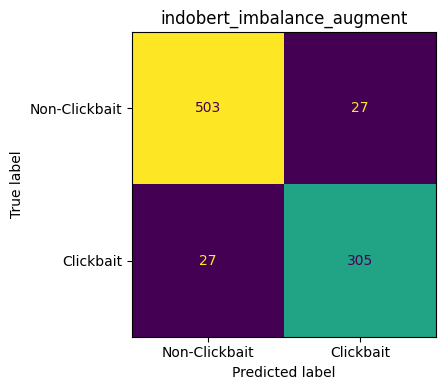

,experiment,model,train_rows,val_f1,val_f1_macro,test_accuracy,test_precision,test_recall,test_f1,test_f1_weighted,test_f1_macro,best_checkpoint,best_model_dir
0,indobert_imbalance,indobenchmark/indobert-base-p1,6889,0.9495,0.9495,0.9362,0.9347,0.9301,0.9360,0.9360,0.9323,/content/drive/MyDrive/NLPAOL_V3/output_indobe...,/content/drive/MyDrive/NLPAOL_V3/output_indobe...
1,indobert_balance,indobenchmark/indobert-base-p1,8474,0.9570,0.9570,0.9420,0.9423,0.9348,0.9417,0.9417,0.9383,/content/drive/MyDrive/NLPAOL_V3/output_indobe...,/content/drive/MyDrive/NLPAOL_V3/output_indobe...
2,indobert_imbalance_augment,indobenchmark/indobert-base-p1,13778,0.9560,0.9560,0.9374,0.9339,0.9339,0.9374,0.9374,0.9339,/content/drive/MyDrive/NLPAOL_V3/output_indobe...,/content/drive/MyDrive/NLPAOL_V3/output_indobe...


In [16]:
print("Creating Imbalance + Augment data...")

imbalance_aug_texts = eda_augment(
    train_imbalance[
        "title_clean"
    ].tolist()
)

df_imbalance_aug = (
    train_imbalance.copy()
)
df_imbalance_aug["title_clean"] = (
    imbalance_aug_texts
)

train_imbalance_clean = (
    train_imbalance.drop(
        columns=["_row_id"],
        errors="ignore",
    )
)
df_imbalance_aug_clean = (
    df_imbalance_aug.drop(
        columns=["_row_id"],
        errors="ignore",
    )
)

train_imbalance_augment = (
    pd.concat(
        [
            train_imbalance_clean,
            df_imbalance_aug_clean,
        ]
    )
    .sample(
        frac=1,
        random_state=SEED,
    )
    .reset_index(drop=True)
)

print(
    "[Imbalance + Augment]"
)
print(
    train_imbalance_augment[
        LABEL_COL
    ].value_counts()
)

result = train_and_evaluate(
    train_imbalance_augment,
    val_ds,
    test_ds,
    "indobert_imbalance_augment",
)

all_results.append(result)
display(pd.DataFrame(all_results))


## 16. Experiment 4: Balance + Augmentation


Experiment : indobert_balance_augment
Train rows : 16,948
label
clickbait        8474
non-clickbait    8474


Map:   0%|          | 0/16948 [00:00<?, ? examples/s]

{'loss': 0.7322, 'grad_norm': 5.398247718811035, 'learning_rate': 9.442870632672334e-07, 'epoch': 0.04719207173194903}
{'loss': 0.5675, 'grad_norm': 6.222331523895264, 'learning_rate': 1.8885741265344667e-06, 'epoch': 0.09438414346389806}
{'loss': 0.3737, 'grad_norm': 2.8345508575439453, 'learning_rate': 2.8328611898017e-06, 'epoch': 0.1415762151958471}
{'loss': 0.2847, 'grad_norm': 10.103473663330078, 'learning_rate': 3.7771482530689335e-06, 'epoch': 0.18876828692779613}
{'loss': 0.2665, 'grad_norm': 11.354190826416016, 'learning_rate': 4.721435316336166e-06, 'epoch': 0.23596035865974516}
{'loss': 0.2548, 'grad_norm': 10.006139755249023, 'learning_rate': 5.6657223796034e-06, 'epoch': 0.2831524303916942}
{'loss': 0.2403, 'grad_norm': 11.560373306274414, 'learning_rate': 6.6100094428706325e-06, 'epoch': 0.33034450212364325}
{'loss': 0.1821, 'grad_norm': 3.8122124671936035, 'learning_rate': 7.554296506137867e-06, 'epoch': 0.37753657385559225}
{'loss': 0.2165, 'grad_norm': 2.1894581317901

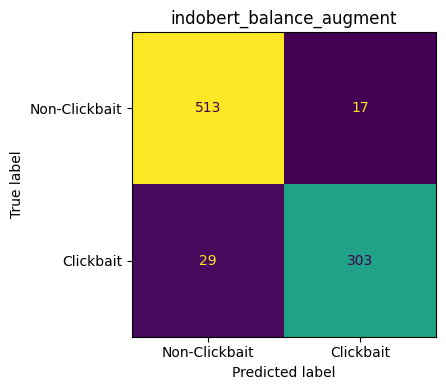

,experiment,model,train_rows,val_f1,val_f1_macro,test_accuracy,test_precision,test_recall,test_f1,test_f1_weighted,test_f1_macro,best_checkpoint,best_model_dir
0,indobert_imbalance,indobenchmark/indobert-base-p1,6889,0.9495,0.9495,0.9362,0.9347,0.9301,0.9360,0.9360,0.9323,/content/drive/MyDrive/NLPAOL_V3/output_indobe...,/content/drive/MyDrive/NLPAOL_V3/output_indobe...
1,indobert_balance,indobenchmark/indobert-base-p1,8474,0.9570,0.9570,0.9420,0.9423,0.9348,0.9417,0.9417,0.9383,/content/drive/MyDrive/NLPAOL_V3/output_indobe...,/content/drive/MyDrive/NLPAOL_V3/output_indobe...
2,indobert_imbalance_augment,indobenchmark/indobert-base-p1,13778,0.9560,0.9560,0.9374,0.9339,0.9339,0.9374,0.9374,0.9339,/content/drive/MyDrive/NLPAOL_V3/output_indobe...,/content/drive/MyDrive/NLPAOL_V3/output_indobe...
3,indobert_balance_augment,indobenchmark/indobert-base-p1,16948,0.9472,0.9472,0.9466,0.9467,0.9403,0.9464,0.9464,0.9433,/content/drive/MyDrive/NLPAOL_V3/output_indobe...,/content/drive/MyDrive/NLPAOL_V3/output_indobe...


In [17]:
result = train_and_evaluate(
    train_balance_augment,
    val_ds,
    test_ds,
    "indobert_balance_augment",
)

all_results.append(result)
display(pd.DataFrame(all_results))


## 17. Result Summary

In [18]:

results_df = pd.DataFrame(all_results)

summary_path = (
    RESULTS_DIR
    / "indobert_experiment_summary.csv"
)
legacy_summary_path = (
    RESULTS_DIR
    / "indobert_all_experiments.csv"
)

results_df.to_csv(
    summary_path,
    index=False,
)
results_df.to_csv(
    legacy_summary_path,
    index=False,
)

display(
    results_df[
        [
            "experiment",
            "train_rows",
            "val_f1",
            "val_f1_macro",
            "test_accuracy",
            "test_precision",
            "test_recall",
            "test_f1_weighted",
            "test_f1_macro",
        ]
    ].sort_values(
        "test_f1_macro",
        ascending=False,
    )
)

best_by_validation = (
    results_df.sort_values(
        "val_f1_macro",
        ascending=False,
    ).iloc[0]
)

best_by_test = (
    results_df.sort_values(
        "test_f1_macro",
        ascending=False,
    ).iloc[0]
)

print("\nBest by validation macro F1")
print(
    best_by_validation[
        [
            "experiment",
            "val_f1_macro",
        ]
    ]
)

print("\nHighest test macro F1")
print(
    best_by_test[
        [
            "experiment",
            "test_accuracy",
            "test_f1_macro",
            "test_f1_weighted",
        ]
    ]
)

print("\nSaved:")
print("-", summary_path)
print("-", legacy_summary_path)



,experiment,train_rows,val_f1,val_f1_macro,test_accuracy,test_precision,test_recall,test_f1_weighted,test_f1_macro
3,indobert_balance_augment,16948,0.9472,0.9472,0.9466,0.9467,0.9403,0.9464,0.9433
1,indobert_balance,8474,0.9570,0.9570,0.9420,0.9423,0.9348,0.9417,0.9383
2,indobert_imbalance_augment,13778,0.9560,0.9560,0.9374,0.9339,0.9339,0.9374,0.9339
0,indobert_imbalance,6889,0.9495,0.9495,0.9362,0.9347,0.9301,0.9360,0.9323



Best by validation macro F1
experiment      indobert_balance
val_f1_macro               0.957
Name: 1, dtype: object

Highest test macro F1
experiment          indobert_balance_augment
test_accuracy                         0.9466
test_f1_macro                         0.9433
test_f1_weighted                      0.9464
Name: 3, dtype: object

Saved:
- /content/drive/MyDrive/NLPAOL_V3/output_indobert_final/results/indobert_experiment_summary.csv
- /content/drive/MyDrive/NLPAOL_V3/output_indobert_final/results/indobert_all_experiments.csv


## 18. Export Final Deployment Model

In [21]:
# Select the deployment model using the highest TEST macro F1.
# (validation macro F1 is only used for per-epoch checkpoint
# selection inside each experiment; the FINAL choice among the
# 4 strategies must use the held-out test set, per the paper.)
DEPLOY_EXPERIMENT = str(
    best_by_test["experiment"]
)

source_model_dir = (
    CHECKPOINT_DIR
    / DEPLOY_EXPERIMENT
    / "best_model"
)

deploy_dir = (
    DEPLOY_ROOT
    / DEPLOY_EXPERIMENT
)

if not source_model_dir.exists():
    raise FileNotFoundError(
        f"Model directory not found: "
        f"{source_model_dir}"
    )

if deploy_dir.exists():
    shutil.rmtree(deploy_dir)

deploy_dir.mkdir(
    parents=True,
    exist_ok=True,
)

final_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        str(source_model_dir)
    )
)

final_tokenizer = (
    AutoTokenizer.from_pretrained(
        str(source_model_dir)
    )
)

final_model.config.num_labels = 2
final_model.config.id2label = ID2LABEL
final_model.config.label2id = LABEL2ID
final_model.config.problem_type = (
    "single_label_classification"
)

final_model.save_pretrained(
    str(deploy_dir),
    safe_serialization=True,
)

final_tokenizer.save_pretrained(
    str(deploy_dir)
)

save_binary_config(
    deploy_dir
)

runtime_config = {
    "model_name": DEPLOY_EXPERIMENT,
    "base_model": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "temperature": 1.0,
    "threshold": 0.5,
    "selection_metric": "test_macro_f1",
    "label_mapping": {
        "0": "non-clickbait",
        "1": "clickbait",
    },
}

with open(
    deploy_dir / "runtime_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        runtime_config,
        file,
        indent=2,
        ensure_ascii=False,
    )

print(
    "Selected deployment experiment:",
    DEPLOY_EXPERIMENT,
)

print(
    "Test macro F1:",
    best_by_test["test_f1_macro"],
)

print(
    "Deployment model saved to:",
    deploy_dir,
)

print("\nFiles:")
for file_path in sorted(
    deploy_dir.iterdir()
):
    print("-", file_path.name)

Selected deployment experiment: indobert_balance_augment
Test macro F1: 0.9433
Deployment model saved to: /content/drive/MyDrive/NLPAOL_V3/output_indobert_final/final_deploy/indobert_balance_augment

Files:
- config.json
- model.safetensors
- runtime_config.json
- special_tokens_map.json
- tokenizer.json
- tokenizer_config.json
- vocab.txt


## 19. Final Model Sanity Check

In [22]:
test_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        str(deploy_dir)
    )
)
test_tokenizer = (
    AutoTokenizer.from_pretrained(
        str(deploy_dir)
    )
)

test_model.to(DEVICE)
test_model.eval()


def predict_headline(
    text: str,
):
    cleaned = clean_text(text)

    inputs = test_tokenizer(
        cleaned,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

    inputs = {
        key: value.to(DEVICE)
        for key, value
        in inputs.items()
    }

    with torch.no_grad():
        logits = test_model(
            **inputs
        ).logits

        probabilities = (
            torch.softmax(
                logits,
                dim=1,
            )[0]
            .cpu()
            .numpy()
        )

    return {
        "headline": text,
        "non_clickbait": round(
            float(probabilities[0]),
            4,
        ),
        "clickbait": round(
            float(probabilities[1]),
            4,
        ),
        "prediction": (
            "clickbait"
            if probabilities[1] >= 0.5
            else "non-clickbait"
        ),
    }


examples = [
    (
        "Pemerintah Tetapkan Libur "
        "Nasional Baru untuk Tahun 2026"
    ),
    (
        "Harga Beras di Pasar Tradisional "
        "Mengalami Kenaikan"
    ),
    (
        "7 Fakta Mengejutkan tentang Artis "
        "Ini Nomor 4 Bikin Kaget"
    ),
]

sanity_df = pd.DataFrame(
    [
        predict_headline(text)
        for text in examples
    ]
)

display(sanity_df)

sanity_path = (
    RESULTS_DIR
    / "final_model_sanity_check.csv"
)

sanity_df.to_csv(
    sanity_path,
    index=False,
)

print(
    "Sanity check saved to:",
    sanity_path,
)


,headline,non_clickbait,clickbait,prediction
0,Pemerintah Tetapkan Libur Nasional Baru untuk ...,0.9994,0.0006,non-clickbait
1,Harga Beras di Pasar Tradisional Mengalami Ken...,0.9994,0.0006,non-clickbait
2,7 Fakta Mengejutkan tentang Artis Ini Nomor 4 ...,0.0004,0.9996,clickbait


Sanity check saved to: /content/drive/MyDrive/NLPAOL_V3/output_indobert_final/results/final_model_sanity_check.csv
